In [1]:
!pip install tensorflow
!pip install optuna
!pip install scikit-learn
!pip install seaborn
!pip install split-folders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.5 MB/s eta 0:00:00


In [2]:
!curl -L -o ./brain-mri-images-for-brain-tumor-detection.zip https://www.kaggle.com/api/v1/datasets/download/navoneel/brain-mri-images-for-brain-tumor-detection

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 15.0M  100 15.0M    0     0  17.1M      0 --:--:-- --:--:-- --:--:-- 62.6M


In [3]:
!unzip ./brain-mri-images-for-brain-tumor-detection.zip -d ./raw-dataset

Archive:  ./brain-mri-images-for-brain-tumor-detection.zip
  inflating: ./raw-dataset/brain_tumor_dataset/no/1 no.jpeg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/10 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/11 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/12 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/13 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/14 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/15 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/17 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/18 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/19 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/2 no.jpeg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/20 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/21 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/22 no.jpg  
  inflating: ./raw-dataset/brain_tumor_dataset/no/23 no.jpg  
  inflating

In [4]:
!rm -rf ./raw-dataset/no
!rm -rf ./raw-dataset/yes

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import f1_score, roc_auc_score, recall_score, accuracy_score, classification_report, confusion_matrix


import splitfolders
import optuna
import numpy as np
import random

In [6]:
input_folder = "raw-dataset/brain_tumor_dataset"
output_folder = "dataset"

splitfolders.ratio(
  input=input_folder,
  output=output_folder,
  seed=32,
  ratio=(0.7, 0.2, 0.1)
)

Copying files: 253 files [00:00, 7317.98 files/s]


In [7]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TF Version:", tf.__version__)
gpu = tf.config.list_physical_devices('GPU')
print(f"GPU Name: {tf.test.gpu_device_name()}")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF Version: 2.20.0
GPU Name: /device:GPU:0


In [9]:
# ============================================
# CONFIGURATION
# ===========================================

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE=16
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


In [10]:
def data_augmentation():
  # ============================================
  # IMAGE DATA GENERATOR
  # ===========================================

  train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    preprocessing_function=vgg_preprocess,
  )

  validation_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
  )

  test_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
  )

  # ============================================
  # LOAD IMAGE
  # ===========================================

  train_dir = "dataset/train"
  validation_dir = "dataset/val"
  test_dir = "dataset/test"

  train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED,
  )

  validation_data = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary' ,
    shuffle=False,
    seed=SEED,
  )

  test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=SEED,
  )
  return train_data, validation_data, test_data


In [15]:
# ============================================
# OPTUNA OPTIMATION
# ===========================================

def objective(trial: optuna.Trial):
  trainable = trial.suggest_categorical('trainable', [True, False])
  layers_trainable = trial.suggest_int('layers_trainable', 10, 30, step=5)
  dropout_rate = trial.suggest_float('droprate', 0.25, 0.5, step=0.05)
  n_dense = trial.suggest_int('n_dense', 1, 3)
  lr = trial.suggest_float('learning_rate', 1e-5, 1e-4, log=True)

  base_model = VGG16(
      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
      include_top=False,
      weights='imagenet',
      pooling=None,
  )

  base_model.trainable = trainable
  if trainable:
    for layer in base_model.layers[:-layers_trainable]:
      layer.trainable = False
    for layer in base_model.layers[-layers_trainable:]:
      layer.trainable = True

  input = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
  x = base_model(input, training=False)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(dropout_rate)(x)

  for i in range(n_dense):
    dense_unit = trial.suggest_categorical(f'dense_unit_{i}', [128, 256, 512])
    dense_dropout = trial.suggest_float(f'dense_droprate_{i}', 0.1, 0.4, step=0.05)
    x = layers.Dense(dense_unit, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dense_dropout)(x)

  output = layers.Dense(1, activation='sigmoid')(x)
  model = models.Model(input, output)

  model_opt = optimizers.Adam(learning_rate=lr)
  model.compile(
    optimizer=model_opt,
    loss='binary_crossentropy',
    metrics=[
      'accuracy',
      tf.keras.metrics.Recall(name='recall'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.AUC(name='auc')
    ]
  )

  callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
  ]

  train_data, validation_data, test_data = data_augmentation()
  model.fit(
    train_data,
    validation_data=validation_data,
    epochs=100,
    callbacks=callbacks,
    verbose=0,
    batch_size=BATCH_SIZE,
  )

  # recall and auc for scoring
  validation_data.reset()
  y_prob = model.predict(validation_data).flatten()
  y_pred = (y_prob > 0.5).astype(int)
  y_true = validation_data.classes

  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  auc = roc_auc_score(y_true, y_prob)
  accuracy = accuracy_score(y_true, y_pred)

  trial.set_user_attr('recall', recall)
  trial.set_user_attr('auc', auc)
  trial.set_user_attr('f1', f1)
  trial.set_user_attr('accuracy', accuracy)

  print("===============TRIAL======================")
  print(f"Trial Recall       : {recall}")
  print(f"Trial AUC          : {auc}")
  print(f"Trial F1           : {f1}")
  print(f"Trial Accuracy     : {accuracy}")

  scoring = 0.5 * recall + 0.5 * auc
  return scoring


In [16]:
# =========================================================
# CREATE OPTUNA STUDY
# =========================================================

study = optuna.create_study(direction='maximize', study_name='model-tunning')
study.optimize(objective,n_trials=5)
best_trial = study.best_trial
print("\n================ FINAL =====================")
print(f"Best Score        : {best_trial.value:.4f}")
print(f"Best AUC          : {best_trial.user_attrs['auc']:.4f}")
print(f"Best Recall       : {best_trial.user_attrs['recall']:.4f}")
print(f"Best F1           : {best_trial.user_attrs['f1']:.4f}")
print(f"Best Accuracy     : {best_trial.user_attrs['accuracy']:.4f}")
print(f"Best Params       : {best_trial.params}")

[I 2026-05-24 08:32:11,584] A new study created in memory with name: model-tunning


Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step


[I 2026-05-24 08:34:36,232] Trial 0 finished with value: 0.8870967741935484 and parameters: {'trainable': True, 'layers_trainable': 30, 'droprate': 0.45, 'n_dense': 2, 'learning_rate': 2.5367456655491876e-05, 'dense_unit_0': 128, 'dense_droprate_0': 0.25, 'dense_unit_1': 128, 'dense_droprate_1': 0.4}. Best is trial 0 with value: 0.8870967741935484.


===============TRIAL======================
Trial Recall       : 0.8064516129032258
Trial AUC          : 0.967741935483871
Trial F1           : 0.8771929824561403
Trial Accuracy     : 0.86
Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 457ms/step


[I 2026-05-24 08:36:00,512] Trial 1 finished with value: 0.9040747028862479 and parameters: {'trainable': True, 'layers_trainable': 10, 'droprate': 0.25, 'n_dense': 3, 'learning_rate': 1.4053885808467729e-05, 'dense_unit_0': 256, 'dense_droprate_0': 0.30000000000000004, 'dense_unit_1': 512, 'dense_droprate_1': 0.4, 'dense_unit_2': 512, 'dense_droprate_2': 0.2}. Best is trial 1 with value: 0.9040747028862479.


...

===============TRIAL======================
Trial Recall       : 0.9032258064516129
Trial AUC          : 0.9643463497453311
Trial F1           : 0.9180327868852459
Trial Accuracy     : 0.9
Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step


[I 2026-05-24 08:37:45,251] Trial 3 finished with value: 0.765704584040747 and parameters: {'trainable': True, 'layers_trainable': 20, 'droprate': 0.3, 'n_dense': 3, 'learning_rate': 3.652958569391035e-05, 'dense_unit_0': 128, 'dense_droprate_0': 0.1, 'dense_unit_1': 512, 'dense_droprate_1': 0.2, 'dense_unit_2': 128, 'dense_droprate_2': 0.25}. Best is trial 2 with value: 0.9337860780984719.


===============TRIAL======================
Trial Recall       : 0.8709677419354839
Trial AUC          : 0.6604414261460103
Trial F1           : 0.75
Trial Accuracy     : 0.64
Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step


[I 2026-05-24 08:38:50,000] Trial 4 finished with value: 0.36502546689303905 and parameters: {'trainable': True, 'layers_trainable': 10, 'droprate': 0.25, 'n_dense': 2, 'learning_rate': 5.0425415724117734e-05, 'dense_unit_0': 128, 'dense_droprate_0': 0.2, 'dense_unit_1': 128, 'dense_droprate_1': 0.35}. Best is trial 2 with value: 0.9337860780984719.


===============TRIAL======================
Trial Recall       : 0.03225806451612903
Trial AUC          : 0.6977928692699491
Trial F1           : 0.0625
Trial Accuracy     : 0.4

================ FINAL =====================
Best Score        : 0.9338
Best AUC          : 0.9643
Best Recall       : 0.9032
Best F1           : 0.9180
Best Accuracy     : 0.9000
Best Params       : {'trainable': True, 'layers_trainable': 10, 'droprate': 0.25, 'n_dense': 2, 'learning_rate': 4.366831717532208e-05, 'dense_unit_0': 256, 'dense_droprate_0': 0.30000000000000004, 'dense_unit_1': 256, 'dense_droprate_1': 0.4}


In [17]:
# =========================================================
# TRAIN FINAL MODEL AFTER OPTUNA OPTIMAZTION TUNING
# WITH BEST SCORING
# =========================================================
params = best_trial.params
trainable = params['trainable']
layers_trainable = params['layers_trainable']
dropout_rate = params['droprate']
n_dense = params['n_dense']
lr = params['learning_rate']

base_model_best_trial = VGG16(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet',
    pooling=None,
)

base_model_best_trial.trainable = trainable
if trainable:
  for layer in base_model_best_trial.layers[:-layers_trainable]:
    layer.trainable = False
  for layer in base_model_best_trial.layers[-layers_trainable:]:
    layer.trainable = True

input_best_trial = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x_best_trial = base_model_best_trial(input_best_trial, training=False)
x_best_trial = layers.GlobalAveragePooling2D()(x_best_trial)
x_best_trial = layers.BatchNormalization()(x_best_trial)
x_best_trial = layers.Dropout(dropout_rate)(x_best_trial)

for i in range(n_dense):
  dense_unit = params[f'dense_unit_{i}']
  dense_dropout = params[f'dense_droprate_{i}']
  x_best_trial = layers.Dense(dense_unit, activation='relu')(x_best_trial)
  x_best_trial = layers.BatchNormalization()(x_best_trial)
  x_best_trial = layers.Dropout(dense_dropout)(x_best_trial)

output_best_trial = layers.Dense(1, activation='sigmoid')(x_best_trial)
model_best_trial = models.Model(input_best_trial, output_best_trial)

model_opt = optimizers.Adam(learning_rate=lr)
model_best_trial.compile(
  optimizer=model_opt,
  loss='binary_crossentropy',
  metrics=[
    'accuracy',
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.AUC(name='auc')
  ]
)

model_best_trial.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,916,161 (56.90 MB)

 Trainable params: 13,768,705 (52.52 MB)

 Non-trainable params: 1,147,456 (4.38 MB)

In [18]:
# =========================================================
# MODEL FIT WITH BEST PARAM
# =========================================================

callbacks = [
  tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min'),
  tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
]

train_data, validation_data, test_data = data_augmentation()
history_best_trial = model_best_trial.fit(
  train_data,
  validation_data=validation_data,
  epochs=100,
  callbacks=callbacks,
  verbose=1,
  batch_size=BATCH_SIZE,
)

# f1 score validation data
validation_data.reset()
y_prob = model_best_trial.predict(validation_data).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = validation_data.classes

recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

Found 176 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 27 images belonging to 2 classes.
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 560ms/step - accuracy: 0.5739 - auc: 0.5872 - loss: 0.8405 - precision: 0.6737 - recall: 0.5926 - val_accuracy: 0.4800 - val_auc: 0.5543 - val_loss: 0.9674 - val_precision: 0.6923 - val_recall: 0.2903 - learning_rate: 4.3668e-05
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 311ms/step - accuracy: 0.6250 - auc: 0.6839 - loss: 0.7598 - precision: 0.7442 - recall: 0.5926 - val_accuracy: 0.6000 - val_auc: 0.6562 - val_loss: 0.8011 - val_precision: 0.7895 - val_recall: 0.4839 - learning_rate: 4.3668e-05
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 325ms/step - accuracy: 0.6136 - auc: 0.7026 - loss: 0.7082 - precision: 0.7273 - recall: 0.5926 - val_accuracy: 0.7200 - val_auc: 0.7759 - val_loss: 0.5900 - val_precision: 0.9048 - val_recall: 0.6129 - learning_rate: 4.3668e-05
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 329ms/step - accuracy: 

In [19]:
loss, accuracy, auc, precision, recall = model_best_trial.evaluate(
  test_data,
  verbose=1
)
print(f"\nTest Accuracy: {accuracy}")
print(f"Test Precision: {precision}")
print(f"Test Recall: {recall}")
print(f"Test AUC: {auc}")
print(f"Test Loss: {loss}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.9630 - auc: 1.0000 - loss: 0.1164 - precision: 1.0000 - recall: 0.9375

Test Accuracy: 0.9629629850387573
Test Precision: 1.0
Test Recall: 1.0
Test AUC: 0.9375
Test Loss: 0.11635585874319077


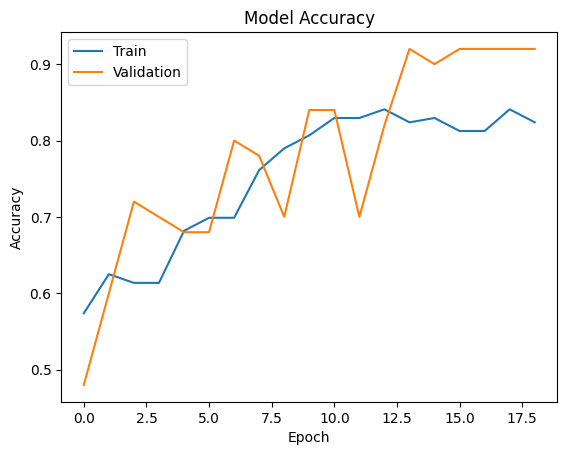

In [20]:
import matplotlib.pyplot as plt

# =========================================================
# VISUALIZATION ACCURACY
# =========================================================

plt.plot(history_best_trial.history['accuracy'])
plt.plot(history_best_trial.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

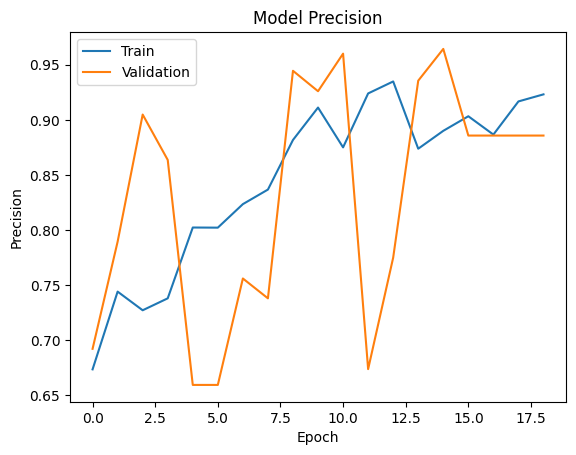

In [21]:
# =========================================================
# VISUALIZATION PRECISION
# =========================================================

plt.plot(history_best_trial.history['precision'])
plt.plot(history_best_trial.history['val_precision'])
plt.title('Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend(['Train', 'Validation'])
plt.show()

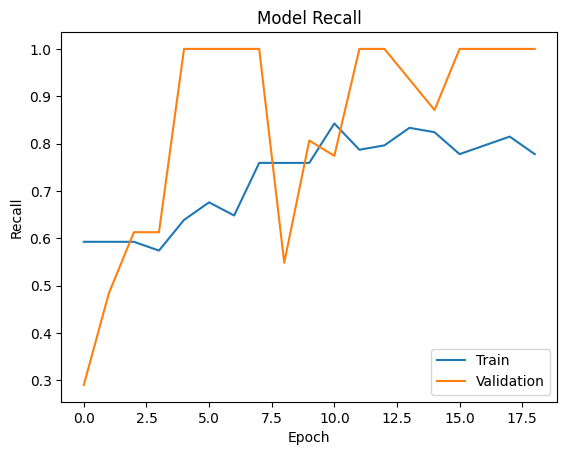

In [22]:
# =========================================================
# VISUALIZATION RECALL
# =========================================================

plt.plot(history_best_trial.history['recall'])
plt.plot(history_best_trial.history['val_recall'])
plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend(['Train', 'Validation'])
plt.show()

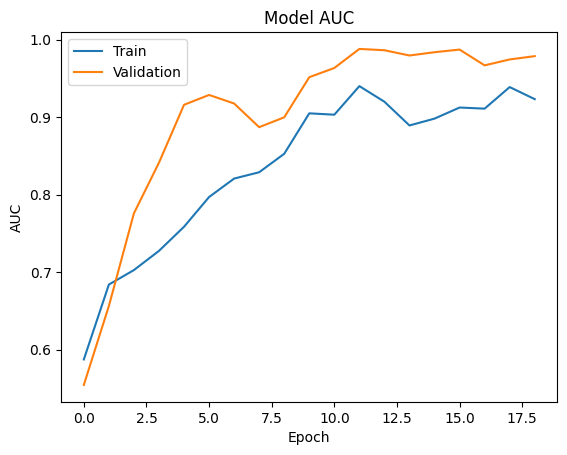

In [23]:
# =========================================================
# VISUALIZATION AUC
# =========================================================

plt.plot(history_best_trial.history['auc'])
plt.plot(history_best_trial.history['val_auc'])
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend(['Train', 'Validation'])
plt.show()

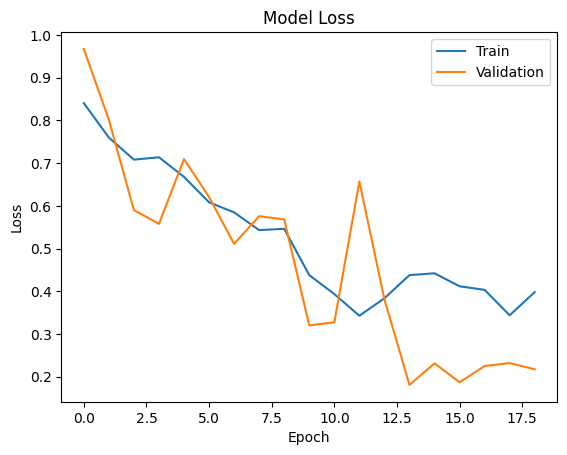

In [24]:
# =========================================================
# VISUALIZATION LOSS
# =========================================================

plt.plot(history_best_trial.history['loss'])
plt.plot(history_best_trial.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [27]:
# =========================================================
# TEST METRIC
# =========================================================

test_data.reset()
y_prob = model_best_trial.predict(test_data).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = test_data.classes

recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
accuracy = accuracy_score(y_true, y_pred)

print("\n================ MODEL =====================")
print(f"Model Recall       : {recall}")
print(f"Model AUC          : {auc}")
print(f"Model F1           : {f1}")
print(f"Model Accuracy     : {accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

================ MODEL =====================
Model Recall       : 0.9375
Model AUC          : 1.0
Model F1           : 0.967741935483871
Model Accuracy     : 0.9629629629629629


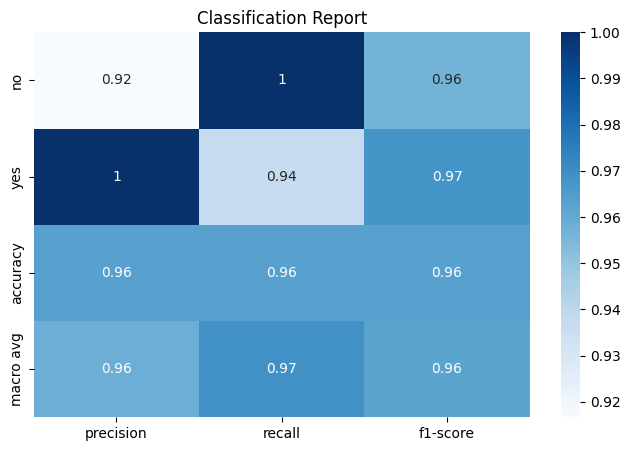

In [28]:
import pandas as pd
import seaborn as sns

class_names = list(train_data.class_indices.keys())
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)
df_report = pd.DataFrame(report_dict).transpose()
plt.figure(figsize=(8, 5))
sns.heatmap(
    df_report.iloc[:-1, :-1],
    annot=True,
    cmap='Blues'
)

plt.title("Classification Report")
plt.show()

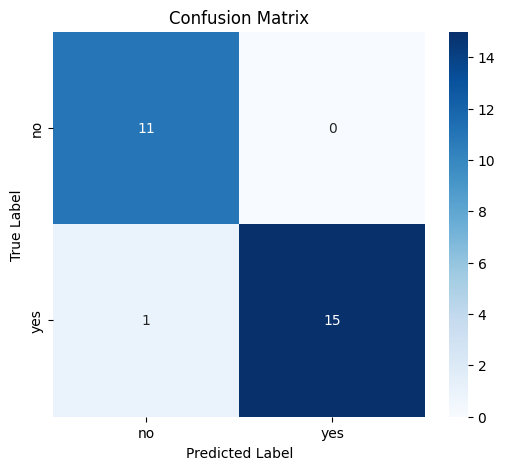

In [29]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()